# **Analisis Penjualan E-Commerce Shopee Indonesia (2024 - 2025)**

**Tools:** Python, Pandas, Seaborn, Matplotlib <br>
**Dataset:** Indonesia E-Commerce Sales & Shipping 2023-2025 <br>
**Tujuan:** Menganalisis pola penjualan dari dimensi produk, waktu, lokasi dan transaksi

In [66]:
import pandas as pd
import numpy as np
import os
import glob

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## **DATA PREPARATION**

In [67]:
folder = "../data/RAW"

all_files = glob.glob(os.path.join(folder, '*.xlsx'))

In [68]:
df_list = []
for file in all_files:
    temp_df = pd.read_excel(file)
    temp_df["source_file"] = os.path.basename(file)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

In [69]:
memory_mb = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Penggunaan memori: {memory_mb:.2f} MB")

Penggunaan memori: 39.90 MB


In [70]:
df.columns = df.columns.str.strip().str.replace(' ', '')
df = df.rename(columns={
    'order_id': 'OrderID',
    'product_category': 'ProductCategory'
})

In [71]:
df.head()

,OrderID,ProductCategory,StatusPesanan,AlasanPembatalan,OpsiPengiriman,WaktuPesananDibuat,MetodePembayaran,Jumlah,Returnedquantity,TotalDiskon,TotalBerat,OngkosKirimDibayarolehPembeli,EstimasiPotonganBiayaPengiriman,TotalPembayaran,PerkiraanOngkosKirim,Kota/Kabupaten,Provinsi,source_file,WaktuPengirimanDiatur,StatusPembatalan/Pengembalian,No.Resi,Antarkecounter/pick-up,PesananHarusDikirimkanSebelum(Menghindariketerlambatan),WaktuPembayaranDilakukan,SKUInduk,NomorReferensiSKU,NamaVariasi,HargaAwal,HargaSetelahDiskon,TotalHargaProduk,DiskonDariPenjual,DiskonDariShopee,BeratProduk,JumlahProdukdiPesan,VoucherDitanggungPenjual,CashbackKoin,VoucherDitanggungShopee,PaketDiskon,PaketDiskon(DiskondariShopee),PaketDiskon(DiskondariPenjual),PotonganKoinShopee,DiskonKartuKredit,OngkosKirimPengembalianBarang,CatatandariPembeli,Catatan,Username(Pembeli),NamaPenerima,No.Telepon,AlamatPengiriman,WaktuPesananSelesai
0,ORD_0000001,Celengan,Selesai,NaN,Reguler (Cashless)-SPX Standard,2024-04-01 00:15,Saldo ShopeePay,1,0.0,0.0,1000 gr,0.0,10.0,38.300,10.0,KOTA SERANG,BANTEN,AprilSales2024_public.xlsx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ORD_0000001,Celengan,Selesai,NaN,Reguler (Cashless)-SPX Standard,2024-04-01 00:15,Saldo ShopeePay,1,0.0,0.0,1000 gr,0.0,10.0,38.300,10.0,KOTA SERANG,BANTEN,AprilSales2024_public.xlsx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ORD_0000002,Celengan,Selesai,NaN,Hemat Kargo-SPX Hemat,2024-04-01 01:47,COD (Bayar di Tempat),1,0.0,0.0,500 gr,0.0,14.5,18.576,14.5,KOTA SEMARANG,JAWA TENGAH,AprilSales2024_public.xlsx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ORD_0000003,Celengan,Selesai,NaN,Hemat Kargo-SPX Hemat,2024-04-01 04:25,SeaBank Bayar Instan,1,0.0,0.0,500 gr,0.0,8.0,7.069,8.0,KAB. BOGOR,JAWA BARAT,AprilSales2024_public.xlsx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ORD_0000004,Mangkok Sambal / Saus,Selesai,NaN,Hemat Kargo-SPX Hemat,2024-04-01 04:41,COD (Bayar di Tempat),2,0.0,0.0,400 gr,0.0,20.0,32.200,20.0,KOTA JAMBI,JAMBI,AprilSales2024_public.xlsx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
print('== Profil Dataset ==')
print(f'Baris: {df.shape[0]}\nKolom: {df.shape[1]} \n')

print('== Nilai Kosong % ==')
missing = df.isna().sum()
missing = (missing[missing > 0]/len(df)*100).round(2)
print(missing, '\n')

print('== Data Duplikat ==')
print(f'Total Duplikat : {df.duplicated().sum()}\nPersentasi Duplikat : {(df.duplicated().sum()/len(df)*100).round(2)}\n')

print('== Tipe Data Kolom ==')
print(df.dtypes)

== Profil Dataset ==
Baris: 26258
Kolom: 50 

== Nilai Kosong % ==
AlasanPembatalan                                            86.58
WaktuPesananDibuat                                           9.27
Returnedquantity                                             5.08
WaktuPengirimanDiatur                                       86.90
StatusPembatalan/Pengembalian                               99.96
No.Resi                                                     94.97
Antarkecounter/pick-up                                      94.97
PesananHarusDikirimkanSebelum(Menghindariketerlambatan)     94.71
WaktuPembayaranDilakukan                                    94.40
SKUInduk                                                   100.00
NomorReferensiSKU                                          100.00
NamaVariasi                                                 97.23
HargaAwal                                                   94.40
HargaSetelahDiskon                                          94.40
TotalHarg

## **DATA CLEANING**

In [73]:
df['Returnedquantity'].value_counts()

Returnedquantity
0.0     24736
1.0       132
2.0        28
3.0        12
6.0         4
4.0         3
5.0         3
17.0        2
18.0        2
25.0        1
Name: count, dtype: int64

In [74]:
# DROP NA

threshold = 50

cols_to_drop = [col for col in df.columns 
                if df[col].isnull().mean() * 100 > threshold]
df = df.drop(columns=cols_to_drop)

print(f"Kolom dihapus ({len(cols_to_drop)}): {cols_to_drop}")

Kolom dihapus (33): ['AlasanPembatalan', 'WaktuPengirimanDiatur', 'StatusPembatalan/Pengembalian', 'No.Resi', 'Antarkecounter/pick-up', 'PesananHarusDikirimkanSebelum(Menghindariketerlambatan)', 'WaktuPembayaranDilakukan', 'SKUInduk', 'NomorReferensiSKU', 'NamaVariasi', 'HargaAwal', 'HargaSetelahDiskon', 'TotalHargaProduk', 'DiskonDariPenjual', 'DiskonDariShopee', 'BeratProduk', 'JumlahProdukdiPesan', 'VoucherDitanggungPenjual', 'CashbackKoin', 'VoucherDitanggungShopee', 'PaketDiskon', 'PaketDiskon(DiskondariShopee)', 'PaketDiskon(DiskondariPenjual)', 'PotonganKoinShopee', 'DiskonKartuKredit', 'OngkosKirimPengembalianBarang', 'CatatandariPembeli', 'Catatan', 'Username(Pembeli)', 'NamaPenerima', 'No.Telepon', 'AlamatPengiriman', 'WaktuPesananSelesai']


In [75]:
df = df.dropna(subset=['WaktuPesananDibuat'])
df['Returnedquantity'] = df['Returnedquantity'].fillna(0)

In [76]:
# DROP DUPLICATE

df = df.drop_duplicates()

In [77]:
# Convert Tipe Data

df['WaktuPesananDibuat'] = pd.to_datetime(df['WaktuPesananDibuat'], errors='coerce')
df['TotalPembayaran'] = (df['TotalPembayaran'].str.replace('.', '')).astype(float)
df['TotalBerat'] = (df['TotalBerat'].str.replace('gr', '')).astype(float)

In [78]:
df = df.rename(columns={
    'TotalBerat': 'TotalBerat(gr)',
    'Returnedquantity': 'ReturnedQuantity'
    })

In [79]:
df = df.drop(columns=('source_file'))

In [80]:
df['ReturnedQuantity'].value_counts()

ReturnedQuantity
0.0     21265
1.0       111
2.0        26
3.0        11
6.0         4
4.0         3
5.0         3
17.0        1
18.0        1
25.0        1
Name: count, dtype: int64

In [81]:
df.head()

,OrderID,ProductCategory,StatusPesanan,OpsiPengiriman,WaktuPesananDibuat,MetodePembayaran,Jumlah,ReturnedQuantity,TotalDiskon,TotalBerat(gr),OngkosKirimDibayarolehPembeli,EstimasiPotonganBiayaPengiriman,TotalPembayaran,PerkiraanOngkosKirim,Kota/Kabupaten,Provinsi
0,ORD_0000001,Celengan,Selesai,Reguler (Cashless)-SPX Standard,2024-04-01 00:15:00,Saldo ShopeePay,1,0.0,0.0,1000.0,0.0,10.0,38300.0,10.0,KOTA SERANG,BANTEN
2,ORD_0000002,Celengan,Selesai,Hemat Kargo-SPX Hemat,2024-04-01 01:47:00,COD (Bayar di Tempat),1,0.0,0.0,500.0,0.0,14.5,18576.0,14.5,KOTA SEMARANG,JAWA TENGAH
3,ORD_0000003,Celengan,Selesai,Hemat Kargo-SPX Hemat,2024-04-01 04:25:00,SeaBank Bayar Instan,1,0.0,0.0,500.0,0.0,8.0,7069.0,8.0,KAB. BOGOR,JAWA BARAT
4,ORD_0000004,Mangkok Sambal / Saus,Selesai,Hemat Kargo-SPX Hemat,2024-04-01 04:41:00,COD (Bayar di Tempat),2,0.0,0.0,400.0,0.0,20.0,32200.0,20.0,KOTA JAMBI,JAMBI
5,ORD_0000005,Other,Batal,Hemat Kargo-SPX Hemat,2024-04-01 06:12:00,COD (Bayar di Tempat),1,0.0,0.0,1200.0,0.0,0.0,0.0,8.0,KOTA TANGERANG,BANTEN


In [82]:
df.shape

(21426, 16)

In [83]:
# df.to_csv("Sales23-25_clean.csv", index=False)

## **Exploratory Data Analysis**

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

### **WHAT**

##### **Produk terlaris**

ProductCategory
Nampan / Tray             9336
Mangkok Sambal / Saus     7543
Celengan                  6921
Aksesoris Pintu           3962
Lunch Box / Rantang       2682
Seal / Baut / Roof        2004
Baskom / Mangkok Besar    1553
Keranjang                 1437
Other                     1221
Botol / Gelas / Mug       1153
Name: Jumlah, dtype: int64


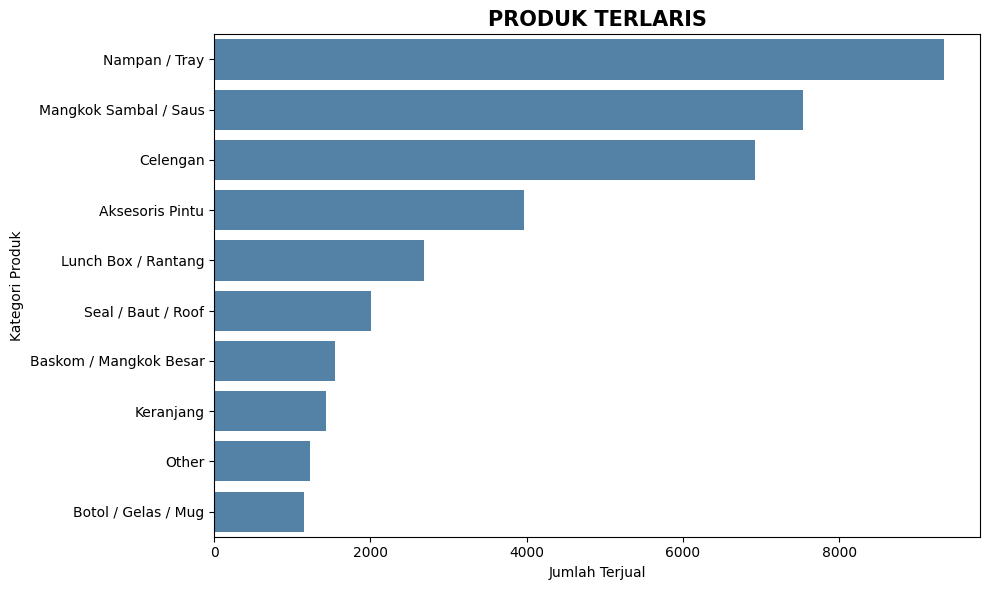

In [85]:
produk_terlaris = df.groupby('ProductCategory')['Jumlah'].sum().sort_values(ascending=False).head(10)
print(produk_terlaris)

plt.figure(figsize=(10, 6))
sns.barplot(
    x = produk_terlaris.values,
    y = produk_terlaris.index,
    color='steelblue'
)
plt.title('Produk Terlaris'.upper(), size=15, weight='bold')
plt.xlabel('Jumlah Terjual')
plt.ylabel('Kategori Produk')
plt.tight_layout()
plt.show()

##### **Produk terbanyak yang dibatalkan**

ProductCategory
Celengan                  598
Mangkok Sambal / Saus     396
Aksesoris Pintu           236
Rak / Rak Serbaguna       198
Nampan / Tray             192
Other                     151
Keranjang                 124
Baskom / Mangkok Besar    115
Lunch Box / Rantang       108
Seal / Baut / Roof         91
Name: StatusPesanan, dtype: int64


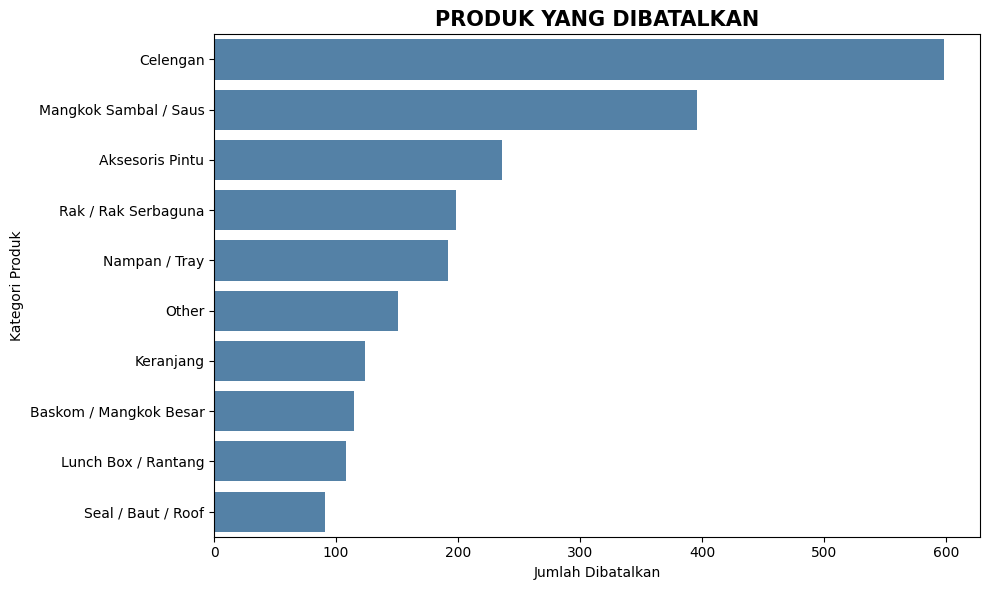

In [86]:
df_batal = df[df['StatusPesanan'] == 'Batal']

batal_terbanyak = df_batal.groupby('ProductCategory')['StatusPesanan'].count().sort_values(ascending=False).head(10)
print(batal_terbanyak)

plt.figure(figsize=(10, 6))
sns.barplot(
    x = batal_terbanyak.values,
    y = batal_terbanyak.index,
    color='steelblue'
)
plt.title('Produk Yang Dibatalkan'.upper(), size=15, weight='bold')
plt.xlabel('Jumlah Dibatalkan')
plt.ylabel('Kategori Produk')
plt.tight_layout()
plt.show()

In [87]:
# Hitung total order dan pembatalan per kategori
total_orders = df.groupby('ProductCategory')['OrderID'].count()
total_batal = df_batal.groupby('ProductCategory')['OrderID'].count()

cancel_rate = (total_batal / total_orders * 100).sort_values(ascending=False).head(10).round(2)

print(cancel_rate)

ProductCategory
Pot Tanaman / Bunga        100.00
Pengolah Bumbu / Sayur      32.24
Rak / Rak Serbaguna         30.79
Mangkok                     25.58
Pisau / Alat Potong         25.29
Piring                      21.88
Aksesoris ID Card           20.31
Toples / Sealware           20.11
Stempel / Alat Kantor       20.00
Sapu / Pembersih Lantai     19.79
Name: OrderID, dtype: float64


Pot Tanaman / Bunga memiliki cancellation rate 100%, namun hanya terdiri dari total 2 order yang keduanya dibatalkan.

INSIGHT:

- Nampan/Tray menjadi produk terlaris dengan demand tinggi dan cancellation rate yang rendah.
- Celengan masuk top 3 produk terlaris tapi juga menjadi produk dengan pembatalan tertinggi nomor 1.
- Pengolahan Bumbu/Sayur dan Rak Serbaguna memiliki cancellation rate tertinggi sekitar 30% transaksi dibatalkan.

### **WHEN**

##### **Tren penjualan bulanan**

In [89]:
df['Tahun'] = df['WaktuPesananDibuat'].dt.year
df['Bulan'] = df['WaktuPesananDibuat'].dt.month
df['NamaBulan'] = df['WaktuPesananDibuat'].dt.strftime('%B')
df['Jam'] = df['WaktuPesananDibuat'].dt.hour
df['HariDalamSeminggu'] = df['WaktuPesananDibuat'].dt.day_name()

In [90]:
df.head()

,OrderID,ProductCategory,StatusPesanan,OpsiPengiriman,WaktuPesananDibuat,MetodePembayaran,Jumlah,ReturnedQuantity,TotalDiskon,TotalBerat(gr),OngkosKirimDibayarolehPembeli,EstimasiPotonganBiayaPengiriman,TotalPembayaran,PerkiraanOngkosKirim,Kota/Kabupaten,Provinsi,Tahun,Bulan,NamaBulan,Jam,HariDalamSeminggu
0,ORD_0000001,Celengan,Selesai,Reguler (Cashless)-SPX Standard,2024-04-01 00:15:00,Saldo ShopeePay,1,0.0,0.0,1000.0,0.0,10.0,38300.0,10.0,KOTA SERANG,BANTEN,2024,4,April,0,Monday
2,ORD_0000002,Celengan,Selesai,Hemat Kargo-SPX Hemat,2024-04-01 01:47:00,COD (Bayar di Tempat),1,0.0,0.0,500.0,0.0,14.5,18576.0,14.5,KOTA SEMARANG,JAWA TENGAH,2024,4,April,1,Monday
3,ORD_0000003,Celengan,Selesai,Hemat Kargo-SPX Hemat,2024-04-01 04:25:00,SeaBank Bayar Instan,1,0.0,0.0,500.0,0.0,8.0,7069.0,8.0,KAB. BOGOR,JAWA BARAT,2024,4,April,4,Monday
4,ORD_0000004,Mangkok Sambal / Saus,Selesai,Hemat Kargo-SPX Hemat,2024-04-01 04:41:00,COD (Bayar di Tempat),2,0.0,0.0,400.0,0.0,20.0,32200.0,20.0,KOTA JAMBI,JAMBI,2024,4,April,4,Monday
5,ORD_0000005,Other,Batal,Hemat Kargo-SPX Hemat,2024-04-01 06:12:00,COD (Bayar di Tempat),1,0.0,0.0,1200.0,0.0,0.0,0.0,8.0,KOTA TANGERANG,BANTEN,2024,4,April,6,Monday


    Tahun  Bulan  TotalPembayaran
0    2023     12       28624045.0
1    2024      1       35610989.0
2    2024      2       25427261.0
3    2024      3       37766764.0
4    2024      4       26089920.0
5    2024      5       43124374.0
6    2024      6       38104136.0
7    2024      7       79672020.0
8    2024      8       81829395.0
9    2024      9       84747039.0
10   2024     10       86730408.0
11   2024     11       68369630.0
12   2025      1       67704342.0
13   2025      2       62093748.0
14   2025      3       54925047.0
15   2025      4       40565070.0
16   2025      5       32153544.0
17   2025      6       38820036.0
18   2025      8       52461981.0
19   2025      9       53056017.0
20   2025     10       76123203.0
21   2025     11       53464530.0


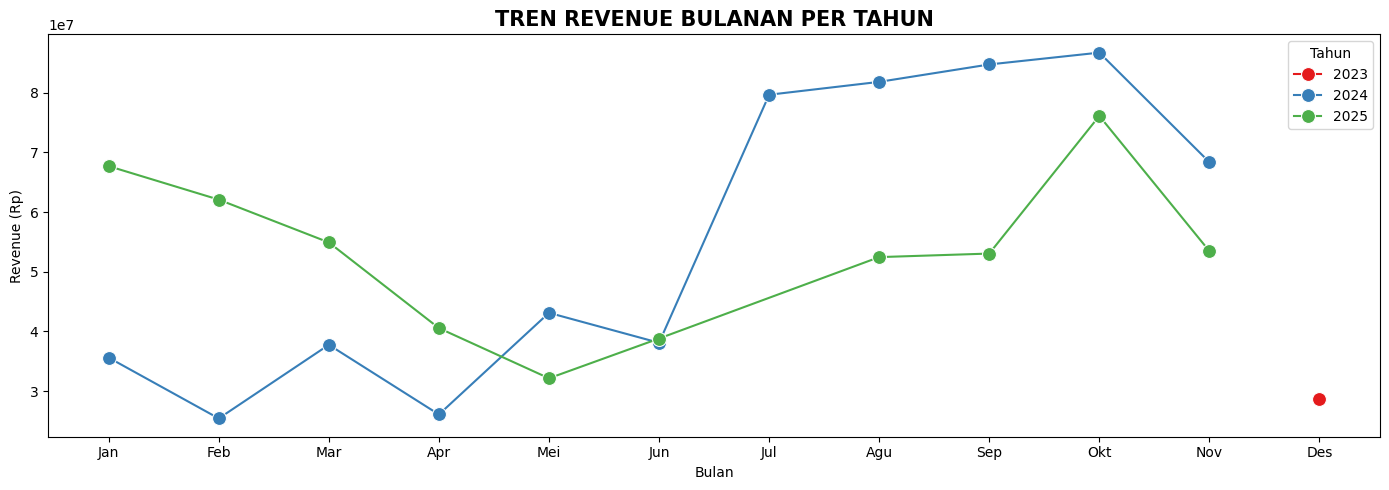

In [91]:
penjualan_bulanan = df.groupby(['Tahun', 'Bulan'])['TotalPembayaran'].sum().reset_index()
print(penjualan_bulanan)

plt.figure(figsize=(14, 5))
sns.lineplot(
    data = penjualan_bulanan,
    x = 'Bulan',
    y = 'TotalPembayaran',
    hue = 'Tahun',
    palette='Set1',
    marker = 'o',
    markersize=10
)
plt.title('Tren Revenue Bulanan per Tahun'.upper(), size=15, weight='bold')
plt.xlabel('Bulan')
plt.ylabel('Revenue (Rp)')
plt.xticks(
    range(1, 13),
    labels=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des'])
plt.tight_layout()
plt.show()

In [92]:
tahun_2024 = df[df['Tahun'] == 2024]
tahun_2025 = df[df['Tahun'] == 2025]

print(f'Revenue Tahun 2024: {tahun_2024["TotalPembayaran"].sum():,.0f}')
print(f'Revenue Tahun 2025: {tahun_2025["TotalPembayaran"].sum():,.0f}')

Revenue Tahun 2024: 607,471,936
Revenue Tahun 2025: 531,367,518


##### **Jam tersibuk**

Jam
0      455
1      226
2      184
3      154
4      251
5      417
6      571
7      833
8     1000
9     1168
10    1252
11    1334
12    1325
13    1314
14    1212
15    1125
16    1138
17    1076
18    1210
19    1234
20    1290
21    1149
22     893
23     615
Name: OrderID, dtype: int64


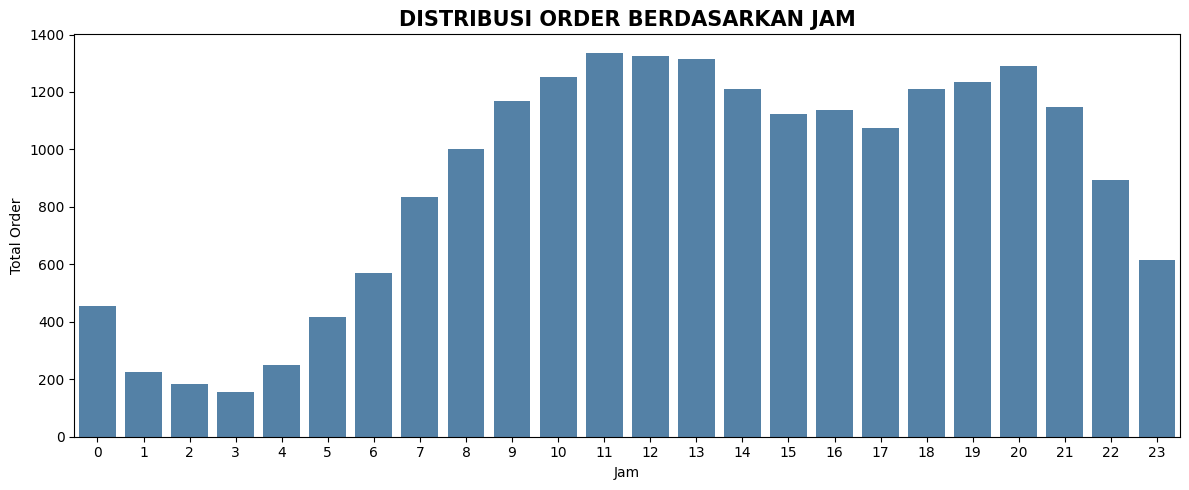

In [93]:
jam_tersibuk = df.groupby('Jam')['OrderID'].count()
print(jam_tersibuk)

plt.figure(figsize=(12, 5))
sns.barplot(
    x = jam_tersibuk.index,
    y = jam_tersibuk.values,
    color='steelblue'
)
plt.title('Distribusi Order Berdasarkan Jam'.upper(), size=15, weight='bold')
plt.xlabel('Jam')
plt.ylabel('Total Order')
plt.tight_layout()
plt.show()

Insight:

- Tahun 2024 punya pola yang jelas, dimana revenue rendah di awal pertengahan tahun lalu melonjak drastis di awal Q3 bulan Juli dan terus naik sampai puncaknya di awal Q4 bulan Oktober.
- Tahun 2025 diawali dari penurunan sampai pertengahan Q2 kemungkinan melanjutkan tren tahun sebelumnya, lalu mengalami kenaikan di bulan Juni hingga puncaknya di bulan Oktober.
- Secara keseluruhan, revenue tahun 2025 lebih rendah dari 2024

(Data tahun 2024 dan 2025 hanya sampai November, dan Juli di tahun 2025 kosong)

### **WHERE**

##### **Provinsi dengan Order Terbanyak dan penghasil Revenue Tertinggi**

In [95]:
df.head()

,OrderID,ProductCategory,StatusPesanan,OpsiPengiriman,WaktuPesananDibuat,MetodePembayaran,Jumlah,ReturnedQuantity,TotalDiskon,TotalBerat(gr),OngkosKirimDibayarolehPembeli,EstimasiPotonganBiayaPengiriman,TotalPembayaran,PerkiraanOngkosKirim,Kota/Kabupaten,Provinsi,Tahun,Bulan,NamaBulan,Jam,HariDalamSeminggu
0,ORD_0000001,Celengan,Selesai,Reguler (Cashless)-SPX Standard,2024-04-01 00:15:00,Saldo ShopeePay,1,0.0,0.0,1000.0,0.0,10.0,38300.0,10.0,KOTA SERANG,BANTEN,2024,4,April,0,Monday
2,ORD_0000002,Celengan,Selesai,Hemat Kargo-SPX Hemat,2024-04-01 01:47:00,COD (Bayar di Tempat),1,0.0,0.0,500.0,0.0,14.5,18576.0,14.5,KOTA SEMARANG,JAWA TENGAH,2024,4,April,1,Monday
3,ORD_0000003,Celengan,Selesai,Hemat Kargo-SPX Hemat,2024-04-01 04:25:00,SeaBank Bayar Instan,1,0.0,0.0,500.0,0.0,8.0,7069.0,8.0,KAB. BOGOR,JAWA BARAT,2024,4,April,4,Monday
4,ORD_0000004,Mangkok Sambal / Saus,Selesai,Hemat Kargo-SPX Hemat,2024-04-01 04:41:00,COD (Bayar di Tempat),2,0.0,0.0,400.0,0.0,20.0,32200.0,20.0,KOTA JAMBI,JAMBI,2024,4,April,4,Monday
5,ORD_0000005,Other,Batal,Hemat Kargo-SPX Hemat,2024-04-01 06:12:00,COD (Bayar di Tempat),1,0.0,0.0,1200.0,0.0,0.0,0.0,8.0,KOTA TANGERANG,BANTEN,2024,4,April,6,Monday


                  JumlahOrder  TotalRevenue
Provinsi                                   
JAWA BARAT               6764   295450329.0
BANTEN                   3900   215794690.0
DKI JAKARTA              3043   161141354.0
JAWA TENGAH              1448    96175992.0
JAWA TIMUR               1543    95671999.0
SUMATERA SELATAN          646    45112341.0
LAMPUNG                   506    26706986.0
SULAWESI SELATAN          242    24943332.0
SUMATERA UTARA            309    22886267.0
BALI                      205    21562532.0


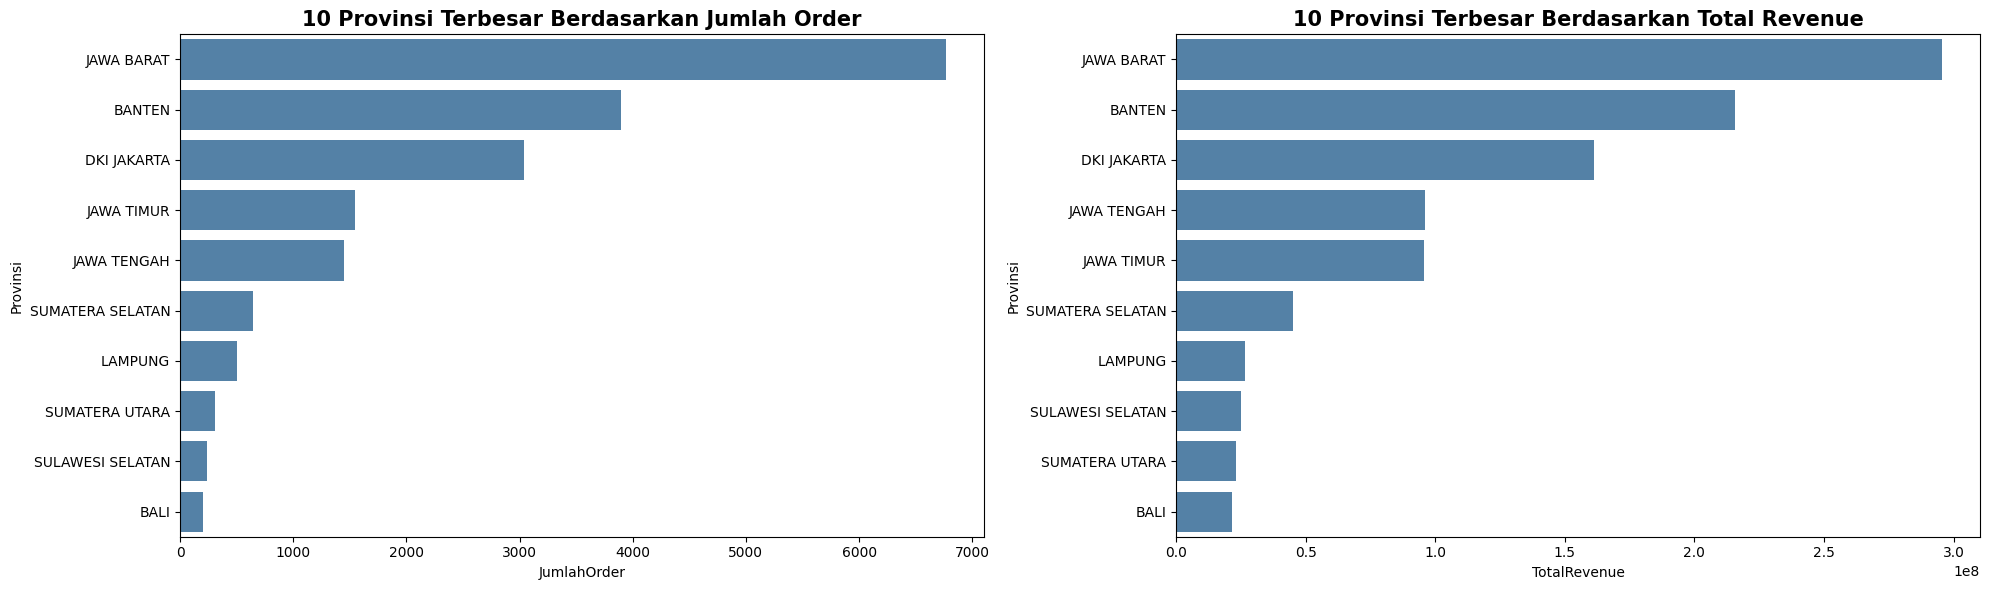

In [96]:
revenue_provinsi = df.groupby('Provinsi').agg(
    JumlahOrder=('OrderID', 'count'),
    TotalRevenue=('TotalPembayaran', 'sum')
).sort_values('TotalRevenue', ascending=False).head(10)
print(revenue_provinsi)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Plot 1
sns.barplot(
    revenue_provinsi.sort_values('JumlahOrder', ascending=False),
    x='JumlahOrder',
    y='Provinsi',
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title('10 Provinsi Terbesar Berdasarkan Jumlah Order', weight='bold', size='15')

# Plot 2
sns.barplot(
    revenue_provinsi,
    x='TotalRevenue',
    y='Provinsi',
    ax=axes[1],
    color='steelblue'
)
axes[1].set_title('10 Provinsi Terbesar Berdasarkan Total Revenue', weight='bold', size='15')

plt.tight_layout()
plt.show()

Insight:

- Jawa Barat mendominasi di kedua aspek, dengan jumlah order terbanyak di 6764 order dan penghasil revenue tertinggi di Rp 295jt, jauh dari provinsi lain.
- Top 3 Provinsi merupakan are Jabodetabek.
- Jawa Timur memiliki jumlah Order lebih banyak daripada Jawa Tengah, tetapi Jawa Tengah unggul di Total Revenue yang dihasilkan walaupun hanya sedikit perbedaannya, di kisaran Rp 500rb
- Pasar di luar pulau Jawa masih kalah jauh, ini menunjukan peluang pasar luar Jawa masih sangat bisa ditingkatkan.

### **HOW**

##### **Distribusi metode pembayaran dan opsi pengiriman**

MetodePembayaran
COD (Bayar di Tempat)        52.13
Saldo ShopeePay              19.02
Online Payment               15.92
SPayLater                     8.00
SeaBank Bayar Instan          3.36
Kartu Kredit/Debit            1.13
Indomaret/i.Saku              0.18
Alfamart/Alfamidi/Dan+Dan     0.16
Pembayaran dibebaskan         0.07
Cicilan Kartu Kredit          0.02
BCA OneKlik                   0.01
Mitra Shopee                  0.00
Name: OrderID, dtype: float64 

OpsiPengiriman
Hemat Kargo-SPX Hemat                            59.59
Reguler (Cashless)-SPX Standard                  21.12
SPX Hemat                                         2.43
Hemat Kargo                                       2.35
Instant (Versi Lama)-SPX Instant (Versi Lama)     2.24
Same Day-SPX Sameday                              1.89
Reguler (Cashless)-JNE Reguler                    1.67
Kargo-JNE Trucking (JTR)                          1.12
Kargo-J&T Cargo                                   1.01
SPX Standard         

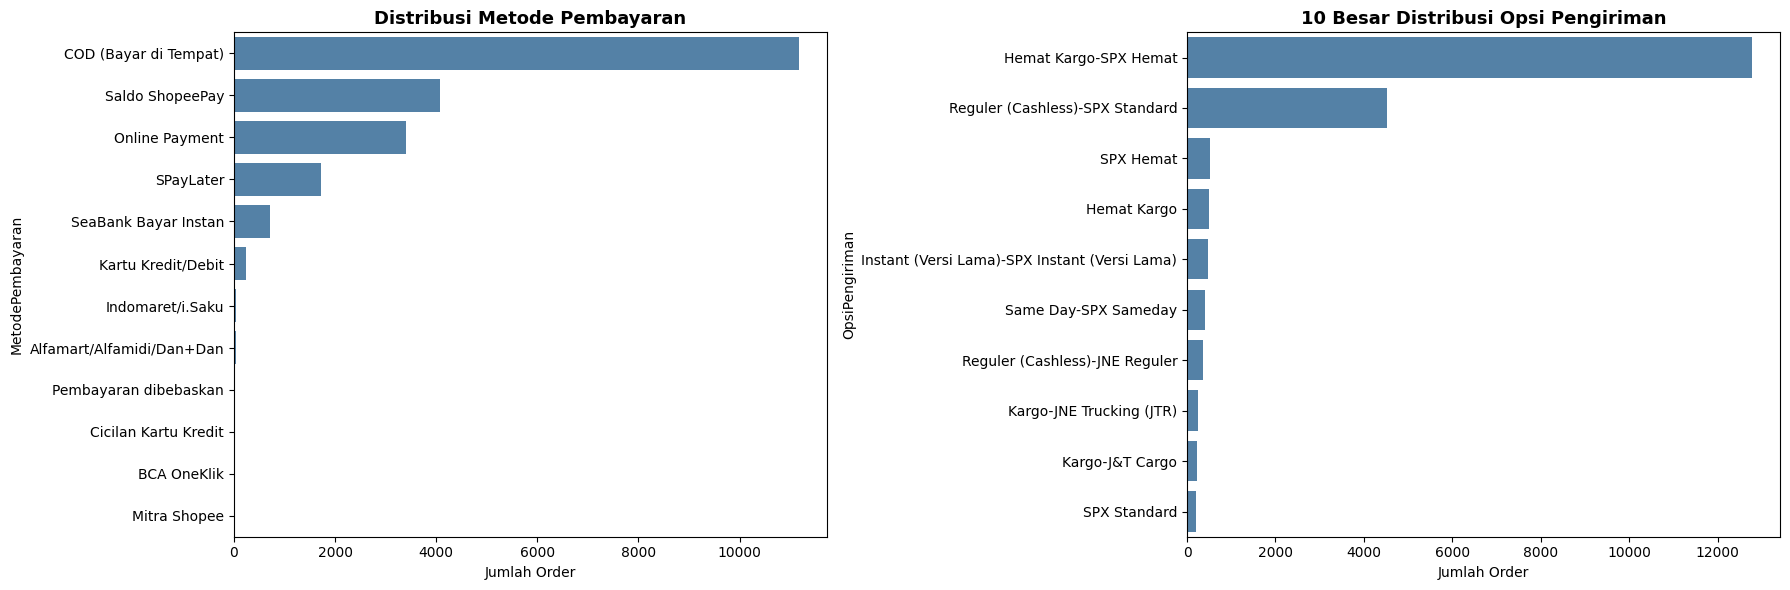

In [98]:
pembayaran = df.groupby('MetodePembayaran')['OrderID'].count().sort_values(ascending=False)
print((pembayaran/len(df) * 100).round(2), '\n')

pengiriman = df.groupby('OpsiPengiriman')['OrderID'].count().sort_values(ascending=False).head(10)
print((pengiriman/len(df) * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1
sns.barplot(
    x = pembayaran.values,
    y = pembayaran.index,
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title('Distribusi Metode Pembayaran', weight='bold', size='13')
axes[0].set_xlabel('Jumlah Order')

# Plot 2
sns.barplot(
    x = pengiriman.values,
    y = pengiriman.index,
    color='steelblue',
    ax=axes[1]
)
axes[1].set_title('10 Besar Distribusi Opsi Pengiriman', weight='bold', size='13')
axes[1].set_xlabel('Jumlah Order')

plt.tight_layout()
plt.show()

Insight:

Metode Pembayaran
- COD dominan dengan 11.169 order (52%). Lebih dari setengah transaksi melakukan COD.
- Shopeepay di posisi ke-2 menunjukkan ekosistem Shopee yang berkerja baik.

Opsi Pengiriman
- Hemat Kargo-SPX Hemat mendominasi jauh di ~60%, ini menandakan pembeli sangat price-sensitive soal ongkir
- Same Day dan Instant sangat kecil, konfirmasi pembeli tidak terlalu memprioritaskan kecepatan

##### **Distribusi nilai transaksi**

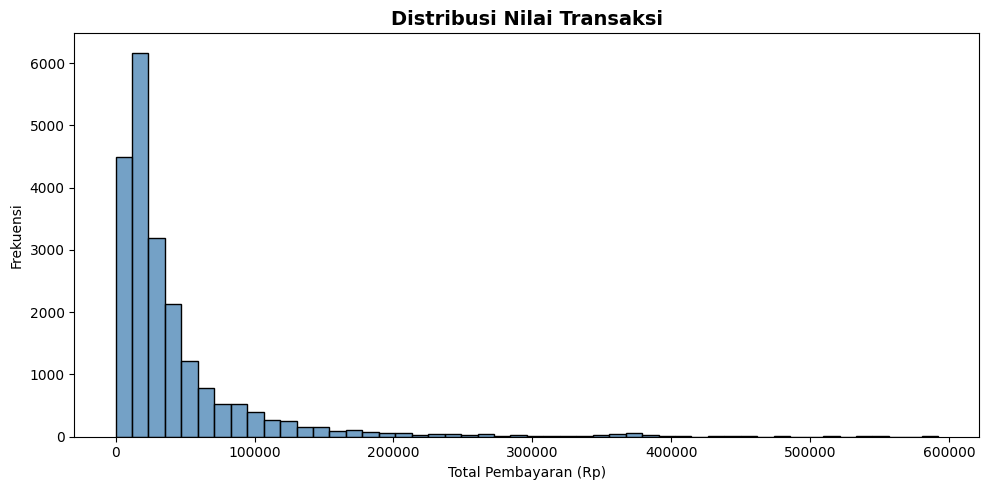

count       Rp 21,426
mean        Rp 54,488
std        Rp 143,686
min              Rp 0
25%         Rp 14,520
50%         Rp 23,920
75%         Rp 47,971
max      Rp 3,076,000
Name: TotalPembayaran, dtype: object


In [99]:
batas_atas = df['TotalPembayaran'].quantile(0.99)
df_filtered = df[df['TotalPembayaran'] <= batas_atas]

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_filtered,
    x='TotalPembayaran',
    bins=50,
    color='steelblue'
)
plt.title('Distribusi Nilai Transaksi', fontsize=14, fontweight='bold')
plt.xlabel('Total Pembayaran (Rp)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Statistik ringkas
print(df['TotalPembayaran'].describe().apply(lambda x: f'Rp {x:,.0f}'))

Insight:

- Median Rp 23.920
- Mean Rp 54.488
- 75% Rp 47.971
- Max Rp 3.076.000

Dari 75% dapat disimpulkan mayoritas membeli produk yang murah, dengan Max yang sangat jauh dari nilai Mean (rata2) nya yang menandakan transaksi nilai besar sangat sedikit.

## **Business Summary**

Analisis ini dilakukan terhadap data transaksi penjualan e-commerce Shopee periode 2024-2025 dengan total 21.426 order. Tujuannya adalah memahami pola penjualan dari 4 dimensi: produk, waktu, lokasi, dan perilaku transaksi, untuk menghasilkan rekomendasi yang actionable bagi tim bisnis.


Temuan Utama:
### 1. Product
Nampan/Tray adalah produk terlaris dengan 9.336 unit terjual dan cancellation rate yang rendah, menandakan demand yang genuine dan stabil. Sebaliknya, celengan memiliki volume penjualan tinggi namun juga pembatalan terbanyak.

### 2. Waktu
Revenue mengalami lonjakan signifikan mulai Juli 2024 dan mencapai puncaknya di Oktober 2024. Di 2025, revenue justru menurun dari Januari hingga Mei 2025, mengindikasikan adanya perubahan tren atau persaingan yang meningkat. Dari sisi harian, jam tersibuk adalah pukul 11:00-13:00 dan 19:00-20:00.

### 3. Lokasi
Jawa Barat mendominasi dengan 6.765 order dan revenue Rp 295 Juta, hampir 3x lipat provinsi kedua. Area Jabodetabek (Jawa Barat, Banten, DKI Jakarta) secara keseluruhan menyumbang lebih dari 70% total transaksi. Pasar luar jawa masih sangat kecil dan merupakan peluang ekspansi.

### 4. Transaksi
Lebih dari 52% pembeli memilih COD sebagai metode pembayaran, dan 60% memilih opsi pengiriman termurah (Hemat Kargo-SPX). Median nilai transaksi hanya Rp 23.920, jauh di bawah mean Rp 54.488 yang terdistori oleh outlier. Profil ini menggambarkan segmen pembeli yang sensitive dengan harga dan kebiasan pembelian produk bernilai kecil.


Rekomendasi:
### 1. Fokus stok pada Nampan/Tray
Demand paling tinggi dan stabil, prioritaskan ketersediaan produk ini terutama menjelang Q3-Q4.

### 2. Investigasi pembatalan produk yang tinggi
Cancellation Rate tinggi perlu di telusuri lebih lanjut, apakah karena masalah stok, deskripsi yang tidak cocok, atau harga yang tidak kompetitif.

### 3. Optimalkan promosi di Peak Hour
Adakan flash sale atau notifikasi di jam2 sibuk untuk memaksimalkan konversi.

### 4. Eksplorasi pasar luar Jawa 
Sumatera dan Sulawesi menunjukkan potensi yang belum dioptimalkan, bisa dijadikan target ekspansi dengan kampanye ongkir gratis.